# Unit Ball Ground-Truth Validation

This notebook validates numerical Dirichlet spectra on the unit ball
\[
\Omega(1,1,1)=\{x\in\mathbb{R}^3:\|x\|<1\}
\]
against the exact eigenvalues
\[
\lambda_{\ell,k}=j_{\ell+1/2,k}^2,
\]
with multiplicity \(2\ell+1\).

It is a **load-only** notebook: solver runs remain in Slurm jobs. It supports FEM--ARPACK and SSG ordered-spectrum validation, multiplicity-aware diagnostics, optional resolvent Block-Hankel landmark validation, and publication-ready exports.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.special import spherical_jn

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

DATA_ROOT = Path.home() / "data"
OUTPUTS_DIR = DATA_ROOT / "outputs"

ARNOLDI_DIR = OUTPUTS_DIR / "arnoldi_reference_sphere"
SSG_DIR = OUTPUTS_DIR / "ssg_reference_sphere"
HANKEL_DIR = OUTPUTS_DIR / "hankel_resolvent_sphere"

ANALYSIS_DIR = OUTPUTS_DIR / "unit_ball_ground_truth_validation"
FIG_DIR = ANALYSIS_DIR / "figures"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_TARGET = 2000
print("Analysis:", ANALYSIS_DIR)

Analysis: /home/esul01/data/outputs/unit_ball_ground_truth_validation


## 1. Locate numerical output files

In [2]:
def first_match(directory: Path, patterns: list[str]):
    for pattern in patterns:
        matches = sorted(directory.glob(pattern))
        if matches:
            return matches[-1]
    return None

ARNOLDI_PATH = first_match(
    ARNOLDI_DIR,
    ["*a1_b1_c1*P2_h0.06*arnoldi*N2000*eigs.txt", "*N2000*eigs.txt"],
)
SSG_PATH = first_match(
    SSG_DIR,
    ["*a1_b1_c1*ssg*N2000*eigs.txt", "*N2000*eigs.txt"],
)
HANKEL_LANDMARKS_CSV = first_match(
    HANKEL_DIR / "analysis",
    ["hankel_seed_aware_landmarks.csv", "*landmarks*.csv"],
)

print("Arnoldi:", ARNOLDI_PATH)
print("SSG:    ", SSG_PATH)
print("Hankel: ", HANKEL_LANDMARKS_CSV)

Arnoldi: /home/esul01/data/outputs/arnoldi_reference_sphere/ellipsoid_a1_b1_c1_P2_h0.06_arnoldi_highacc_N2000_eigs.txt
SSG:     /home/esul01/data/outputs/ssg_reference_sphere/ellipsoid_a1_b1_c1_l36_n20_qr64_qt56_qp112_ssg_N2000_eigs.txt
Hankel:  None


## 2. Generate the exact unit-ball spectrum

In [3]:
def spherical_bessel_roots(l: int, x_max: float, step: float = 0.025) -> np.ndarray:
    grid = np.arange(max(1e-8, 0.5 * step), x_max + step, step)
    vals = spherical_jn(l, grid)
    roots = []
    for i in range(len(grid) - 1):
        y0, y1 = vals[i], vals[i + 1]
        if not (np.isfinite(y0) and np.isfinite(y1)):
            continue
        if y0 == 0.0:
            root = grid[i]
        elif y0 * y1 < 0.0:
            root = brentq(lambda x: spherical_jn(l, x), grid[i], grid[i+1],
                          xtol=1e-14, rtol=1e-14, maxiter=100)
        else:
            continue
        if root > 1e-7 and (not roots or abs(root - roots[-1]) > 1e-9):
            roots.append(root)
    return np.asarray(roots)

def generate_exact_unit_ball_spectrum(n_target=2000, x_max=40.0, l_max=45):
    while True:
        levels = []
        for l in range(l_max + 1):
            roots = spherical_bessel_roots(l, x_max)
            for radial_index, root in enumerate(roots, start=1):
                levels.append({
                    "l": l,
                    "radial_index": radial_index,
                    "root": root,
                    "lambda_exact": root**2,
                    "multiplicity": 2*l + 1,
                })
        levels_df = pd.DataFrame(levels).sort_values("lambda_exact").reset_index(drop=True)

        rows = []
        for level_id, row in levels_df.iterrows():
            for m_slot in range(int(row["multiplicity"])):
                rows.append({
                    "level_id": level_id,
                    "l": int(row["l"]),
                    "radial_index": int(row["radial_index"]),
                    "multiplicity": int(row["multiplicity"]),
                    "m_slot": m_slot,
                    "root": float(row["root"]),
                    "lambda_exact": float(row["lambda_exact"]),
                })
        repeated_df = pd.DataFrame(rows).sort_values("lambda_exact").reset_index(drop=True)
        repeated_df["index"] = np.arange(1, len(repeated_df)+1)

        if len(repeated_df) >= n_target:
            repeated_df = repeated_df.iloc[:n_target].copy()
            cutoff = repeated_df["lambda_exact"].max()
            levels_df = levels_df[levels_df["lambda_exact"] <= cutoff + 1e-10].copy()
            return repeated_df, levels_df

        x_max *= 1.25
        l_max += 10

exact_df, exact_levels_df = generate_exact_unit_ball_spectrum(N_TARGET)
exact_df.to_csv(ANALYSIS_DIR / f"unit_ball_exact_N{N_TARGET}.csv", index=False)
exact_levels_df.to_csv(ANALYSIS_DIR / f"unit_ball_exact_levels_to_N{N_TARGET}.csv", index=False)

print("Repeated eigenvalues:", len(exact_df))
print("Distinct levels:", len(exact_levels_df))
print("lambda_1:", exact_df.iloc[0]["lambda_exact"])
print("pi^2:", np.pi**2)
print("lambda_2000:", exact_df.iloc[-1]["lambda_exact"])
display(exact_df.head(20))

Repeated eigenvalues: 2000
Distinct levels: 119
lambda_1: 9.869604401089353
pi^2: 9.869604401089358
lambda_2000: 1001.6976949414133


,level_id,l,radial_index,multiplicity,m_slot,root,lambda_exact,index
0,0,0,1,1,0,3.141593,9.869604,1
1,1,1,1,3,0,4.493409,20.190729,2
2,1,1,1,3,1,4.493409,20.190729,3
3,1,1,1,3,2,4.493409,20.190729,4
4,2,2,1,5,0,5.763459,33.217462,5
5,2,2,1,5,1,5.763459,33.217462,6
6,2,2,1,5,2,5.763459,33.217462,7
7,2,2,1,5,3,5.763459,33.217462,8
8,2,2,1,5,4,5.763459,33.217462,9
9,3,0,2,1,0,6.283185,39.478418,10


## 3. Load available numerical spectra

In [4]:
def load_positive_sorted(path):
    if path is None or not Path(path).exists():
        return None
    values = np.atleast_1d(np.loadtxt(path)).astype(float)
    return np.sort(values[np.isfinite(values) & (values > 0)])

spectra = {
    "FEM--ARPACK": load_positive_sorted(ARNOLDI_PATH),
    "SSG": load_positive_sorted(SSG_PATH),
}
for method, values in spectra.items():
    if values is None:
        print(method, "not available")
    else:
        print(method, len(values), values[0], values[-1])

FEM--ARPACK 2000 9.878297468804268 1024.7729081672405
SSG 2000 9.869604401090413 1001.697694941389


## 4. Ordered-spectrum validation

In [5]:
def ordered_comparison(method, numerical, exact):
    n = min(len(numerical), len(exact))
    out = exact.iloc[:n][["index","level_id","l","radial_index","multiplicity","lambda_exact"]].copy()
    out["method"] = method
    out["lambda_numerical"] = numerical[:n]
    out["abs_error"] = np.abs(out["lambda_numerical"] - out["lambda_exact"])
    out["rel_error"] = out["abs_error"] / out["lambda_exact"]
    return out

ordered_results = {
    method: ordered_comparison(method, values, exact_df)
    for method, values in spectra.items() if values is not None
}

summary_rows = []
for method, df in ordered_results.items():
    summary_rows.append({
        "method": method,
        "count": len(df),
        "lambda_1": df.iloc[0]["lambda_numerical"],
        "lambda_1_rel_error": df.iloc[0]["rel_error"],
        "lambda_last": df.iloc[-1]["lambda_numerical"],
        "median_rel_error": df["rel_error"].median(),
        "mean_rel_error": df["rel_error"].mean(),
        "max_rel_error": df["rel_error"].max(),
        "hits_le_1e-3": int((df["rel_error"] <= 1e-3).sum()),
        "hits_le_1e-4": int((df["rel_error"] <= 1e-4).sum()),
        "hits_le_1e-5": int((df["rel_error"] <= 1e-5).sum()),
    })

ordered_summary = pd.DataFrame(summary_rows)
ordered_summary.to_csv(ANALYSIS_DIR / "ordered_ground_truth_summary.csv", index=False)
display(ordered_summary)

,method,count,lambda_1,lambda_1_rel_error,lambda_last,median_rel_error,mean_rel_error,max_rel_error,hits_le_1e-3,hits_le_1e-4,hits_le_1e-5
0,FEM--ARPACK,2000,9.878297,8.807919e-04,1024.772908,1.099771e-02,1.148132e-02,2.481748e-02,22,0,0
1,SSG,2000,9.869604,1.074496e-13,1001.697695,1.640851e-14,2.534501e-14,1.122581e-12,2000,2000,2000


## 5. Relative error against eigenvalue index

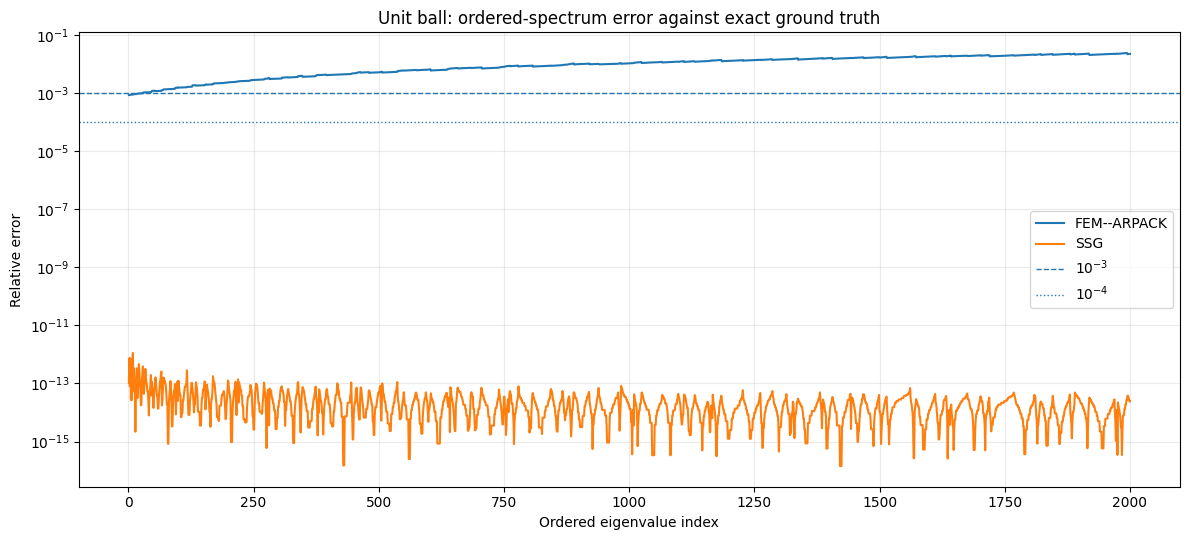

In [6]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for method, df in ordered_results.items():
    ax.semilogy(df["index"], np.maximum(df["rel_error"], 1e-16), label=method)
ax.axhline(1e-3, linestyle="--", linewidth=1, label=r"$10^{-3}$")
ax.axhline(1e-4, linestyle=":", linewidth=1, label=r"$10^{-4}$")
ax.set_xlabel("Ordered eigenvalue index")
ax.set_ylabel("Relative error")
ax.set_title("Unit ball: ordered-spectrum error against exact ground truth")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "unit_ball_relative_error_vs_index.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "unit_ball_relative_error_vs_index.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Relative error against exact eigenvalue

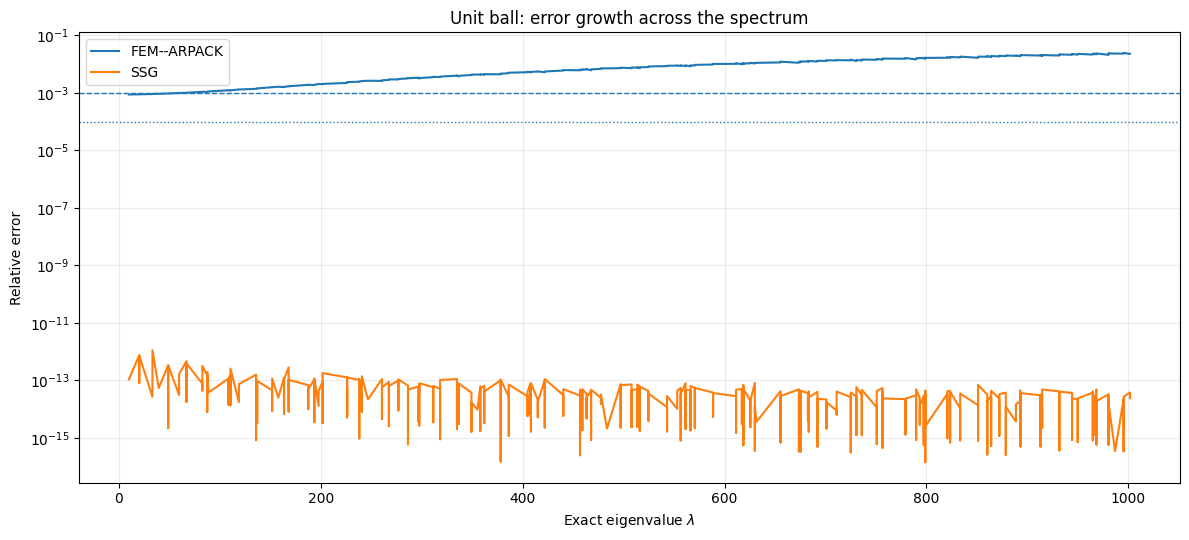

In [7]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for method, df in ordered_results.items():
    ax.semilogy(df["lambda_exact"], np.maximum(df["rel_error"], 1e-16), label=method)
ax.axhline(1e-3, linestyle="--", linewidth=1)
ax.axhline(1e-4, linestyle=":", linewidth=1)
ax.set_xlabel(r"Exact eigenvalue $\lambda$")
ax.set_ylabel("Relative error")
ax.set_title("Unit ball: error growth across the spectrum")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "unit_ball_relative_error_vs_lambda.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "unit_ball_relative_error_vs_lambda.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Multiplicity-aware splitting diagnostics

In [8]:
def multiplicity_diagnostics(method, comparison):
    rows = []
    for level_id, group in comparison.groupby("level_id", sort=True):
        exact_value = float(group["lambda_exact"].iloc[0])
        num = group["lambda_numerical"].to_numpy()
        rows.append({
            "method": method,
            "level_id": int(level_id),
            "l": int(group["l"].iloc[0]),
            "radial_index": int(group["radial_index"].iloc[0]),
            "multiplicity_expected": int(group["multiplicity"].iloc[0]),
            "multiplicity_observed_in_prefix": len(group),
            "lambda_exact": exact_value,
            "lambda_numerical_mean": float(np.mean(num)),
            "relative_center_error": float(abs(np.mean(num)-exact_value)/exact_value),
            "absolute_split_width": float(np.max(num)-np.min(num)),
            "relative_split_width": float((np.max(num)-np.min(num))/exact_value),
        })
    return pd.DataFrame(rows)

multiplicity_results = {
    method: multiplicity_diagnostics(method, df)
    for method, df in ordered_results.items()
}

for method, df in multiplicity_results.items():
    safe = method.lower().replace("-","_").replace(" ","_")
    df.to_csv(ANALYSIS_DIR / f"{safe}_multiplicity_diagnostics.csv", index=False)

display(pd.concat(multiplicity_results.values(), ignore_index=True).head(30))

,method,level_id,l,radial_index,multiplicity_expected,multiplicity_observed_in_prefix,lambda_exact,lambda_numerical_mean,relative_center_error,absolute_split_width,relative_split_width
0,FEM--ARPACK,0,0,1,1,1,9.869604,9.878297,0.000881,0.000000,0.000000
1,FEM--ARPACK,1,1,1,3,3,20.190729,20.208699,0.000890,0.000112,0.000006
2,FEM--ARPACK,2,2,1,5,5,33.217462,33.247690,0.000910,0.000347,0.000010
3,FEM--ARPACK,3,0,2,1,1,39.478418,39.515044,0.000928,0.000000,0.000000
4,FEM--ARPACK,4,3,1,7,7,48.831194,48.877403,0.000946,0.000601,0.000012
5,FEM--ARPACK,5,1,2,3,3,59.679516,59.738586,0.000990,0.000336,0.000006
6,FEM--ARPACK,6,4,1,9,9,66.954312,67.021597,0.001005,0.001070,0.000016
7,FEM--ARPACK,7,2,2,5,5,82.719231,82.809161,0.001087,0.000999,0.000012
8,FEM--ARPACK,8,5,1,11,11,87.531220,87.626877,0.001093,0.001725,0.000020
9,FEM--ARPACK,9,0,3,1,1,88.826440,88.926346,0.001125,0.000000,0.000000


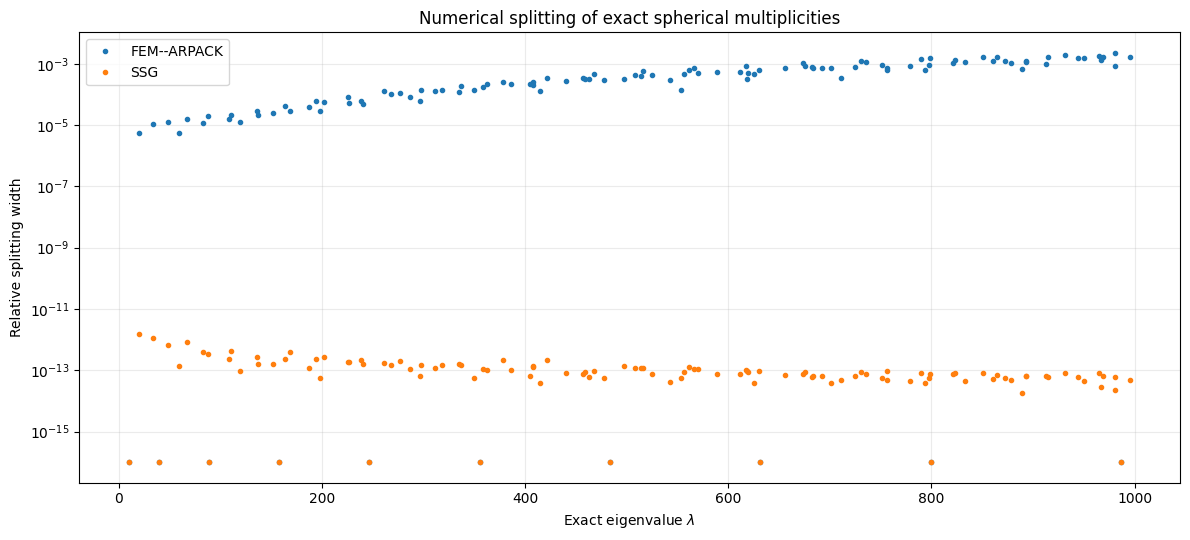

In [9]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for method, df in multiplicity_results.items():
    complete = df["multiplicity_observed_in_prefix"] == df["multiplicity_expected"]
    part = df[complete]
    ax.semilogy(part["lambda_exact"], np.maximum(part["relative_split_width"], 1e-16),
                marker=".", linestyle="none", label=method)
ax.set_xlabel(r"Exact eigenvalue $\lambda$")
ax.set_ylabel("Relative splitting width")
ax.set_title("Numerical splitting of exact spherical multiplicities")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
fig.savefig(FIG_DIR / "unit_ball_multiplicity_splitting.pdf", bbox_inches="tight")
fig.savefig(FIG_DIR / "unit_ball_multiplicity_splitting.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Optional resolvent Block-Hankel landmark validation

In [10]:
def nearest_exact_levels(values, exact_levels):
    levels = exact_levels["lambda_exact"].to_numpy()
    idx = np.searchsorted(levels, values)
    left_idx = np.clip(idx-1, 0, len(levels)-1)
    right_idx = np.clip(idx, 0, len(levels)-1)
    left, right = levels[left_idx], levels[right_idx]
    choose_right = np.abs(right-values) < np.abs(left-values)
    nearest_idx = np.where(choose_right, right_idx, left_idx)
    nearest = levels[nearest_idx]
    out = exact_levels.iloc[nearest_idx].reset_index(drop=True).copy()
    out.insert(0, "lambda_hankel", values)
    out["exact_level_index"] = nearest_idx
    out["rel_error"] = np.abs(values-nearest)/nearest
    return out

hankel_match = None
if HANKEL_LANDMARKS_CSV is not None and HANKEL_LANDMARKS_CSV.exists():
    hankel_df = pd.read_csv(HANKEL_LANDMARKS_CSV).sort_values("lambda_center").reset_index(drop=True)
    hankel_values = hankel_df["lambda_center"].to_numpy()
    hankel_match = nearest_exact_levels(hankel_values, exact_levels_df)
    hankel_match["n_seeds"] = hankel_df["n_seeds"].to_numpy()
    hankel_match.to_csv(ANALYSIS_DIR / "hankel_vs_exact_levels.csv", index=False)
    print("Hankel landmarks:", len(hankel_match))
    print("Median relative error:", hankel_match["rel_error"].median())
    print("Max relative error:", hankel_match["rel_error"].max())
    print("Hits <= 1e-3:", int((hankel_match["rel_error"] <= 1e-3).sum()))
    print("Hits <= 1e-4:", int((hankel_match["rel_error"] <= 1e-4).sum()))
    print("Distinct exact levels hit:", hankel_match["exact_level_index"].nunique())
    display(hankel_match.head(25))
else:
    print("Sphere Hankel landmark CSV not found yet; skipping.")

Sphere Hankel landmark CSV not found yet; skipping.


In [11]:
if hankel_match is not None:
    fig, ax = plt.subplots(figsize=(13, 4.5))
    max_lambda = min(exact_levels_df["lambda_exact"].max(), hankel_match["lambda_hankel"].max()*1.02)
    for value in exact_levels_df.loc[exact_levels_df["lambda_exact"] <= max_lambda, "lambda_exact"]:
        ax.vlines(value, 0.10, 0.38, linewidth=0.5)

    masks = [
        (hankel_match["rel_error"] <= 1e-4, 0.70, 1.00, r"Hankel error $\leq 10^{-4}$"),
        ((hankel_match["rel_error"] > 1e-4) & (hankel_match["rel_error"] <= 1e-3), 0.62, 0.92, r"Hankel error $\leq 10^{-3}$"),
        (hankel_match["rel_error"] > 1e-3, 0.54, 0.84, r"Hankel error $>10^{-3}$"),
    ]
    for mask, y0, y1, label in masks:
        for value in hankel_match.loc[mask, "lambda_hankel"]:
            ax.vlines(value, y0, y1, linewidth=1.5)
        if mask.any():
            ax.plot([], [], linewidth=2, label=label)

    ax.set_xlim(0, max_lambda)
    ax.set_ylim(0, 1.08)
    ax.set_yticks([0.24, 0.77])
    ax.set_yticklabels(["Exact levels", "Hankel"])
    ax.set_xlabel(r"$\lambda$")
    ax.set_title("Unit ball: stable Hankel landmarks against exact spherical levels")
    ax.legend()
    ax.grid(True, axis="x", alpha=0.15)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "unit_ball_hankel_landmarks_vs_exact.pdf", bbox_inches="tight")
    fig.savefig(FIG_DIR / "unit_ball_hankel_landmarks_vs_exact.png", dpi=300, bbox_inches="tight")
    plt.show()

## 9. Final comparative summary

In [12]:
final_rows = summary_rows.copy()
if hankel_match is not None:
    final_rows.append({
        "method": "Resolvent Block-Hankel",
        "count": len(hankel_match),
        "lambda_1": hankel_match.iloc[0]["lambda_hankel"],
        "lambda_1_rel_error": hankel_match.iloc[0]["rel_error"],
        "lambda_last": hankel_match.iloc[-1]["lambda_hankel"],
        "median_rel_error": hankel_match["rel_error"].median(),
        "mean_rel_error": hankel_match["rel_error"].mean(),
        "max_rel_error": hankel_match["rel_error"].max(),
        "hits_le_1e-3": int((hankel_match["rel_error"] <= 1e-3).sum()),
        "hits_le_1e-4": int((hankel_match["rel_error"] <= 1e-4).sum()),
        "hits_le_1e-5": int((hankel_match["rel_error"] <= 1e-5).sum()),
    })

final_summary = pd.DataFrame(final_rows)
final_summary.to_csv(ANALYSIS_DIR / "unit_ball_method_summary.csv", index=False)
display(final_summary)

,method,count,lambda_1,lambda_1_rel_error,lambda_last,median_rel_error,mean_rel_error,max_rel_error,hits_le_1e-3,hits_le_1e-4,hits_le_1e-5
0,FEM--ARPACK,2000,9.878297,8.807919e-04,1024.772908,1.099771e-02,1.148132e-02,2.481748e-02,22,0,0
1,SSG,2000,9.869604,1.074496e-13,1001.697695,1.640851e-14,2.534501e-14,1.122581e-12,2000,2000,2000


## 10. Ground-state sanity check

For the Dirichlet unit ball,
\[
\lambda_1=\pi^2.
\]

In [13]:
ground_truth = np.pi**2
print(f"Exact ground state pi^2 = {ground_truth:.15f}")
for method, values in spectra.items():
    if values is not None:
        print(f"{method:14s} lambda_1={values[0]:.15f} rel_error={abs(values[0]-ground_truth)/ground_truth:.6e}")

Exact ground state pi^2 = 9.869604401089358
FEM--ARPACK    lambda_1=9.878297468804268 rel_error=8.807919e-04
SSG            lambda_1=9.869604401090413 rel_error=1.069097e-13


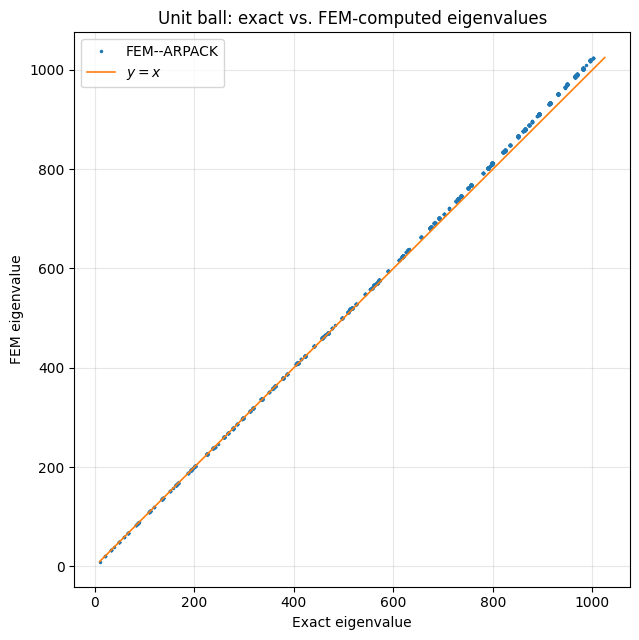

saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_exact_vs_fem.png
saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_exact_vs_fem.pdf


In [14]:
# ============================================================
# Exact vs. FEM eigenvalues
# ============================================================

df_fem = ordered_results["FEM--ARPACK"].copy()

x = df_fem["lambda_exact"].to_numpy()
y = df_fem["lambda_numerical"].to_numpy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.plot(x, y, linestyle="none", marker=".", markersize=3, label="FEM--ARPACK")

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())
ax.plot([lo, hi], [lo, hi], linewidth=1.2, label=r"$y=x$")

ax.set_xlabel("Exact eigenvalue")
ax.set_ylabel("FEM eigenvalue")
ax.set_title("Unit ball: exact vs. FEM-computed eigenvalues")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

out_png = FIG_DIR / "unit_ball_exact_vs_fem.png"
out_pdf = FIG_DIR / "unit_ball_exact_vs_fem.pdf"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("saved:", out_png)
print("saved:", out_pdf)

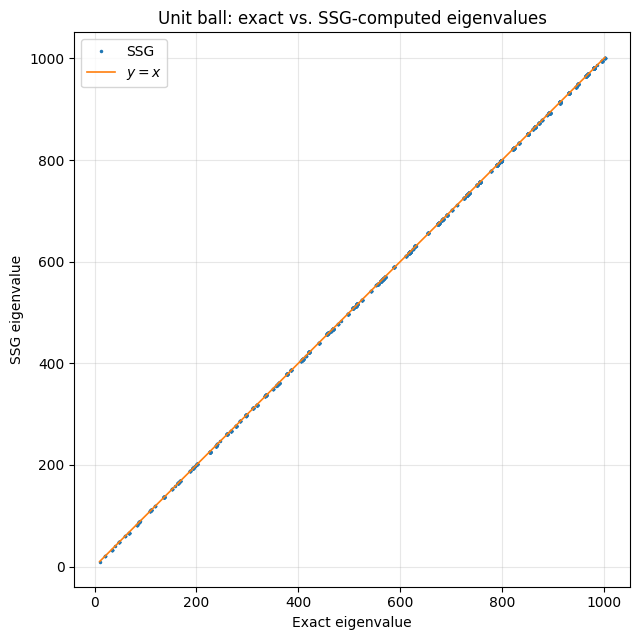

saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_exact_vs_ssg.pdf
saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_exact_vs_ssg.png


In [15]:
# ============================================================
# Unit ball: exact vs. SSG eigenvalues
# ============================================================

df_ssg = ordered_results["SSG"].copy()

x = df_ssg["lambda_exact"].to_numpy()
y = df_ssg["lambda_numerical"].to_numpy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.plot(
    x,
    y,
    linestyle="none",
    marker=".",
    markersize=3,
    label="SSG",
)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())

ax.plot(
    [lo, hi],
    [lo, hi],
    linewidth=1.2,
    label=r"$y=x$",
)

ax.set_xlabel("Exact eigenvalue")
ax.set_ylabel("SSG eigenvalue")
ax.set_title("Unit ball: exact vs. SSG-computed eigenvalues")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

pdf_path = FIG_DIR / "unit_ball_exact_vs_ssg.pdf"
png_path = FIG_DIR / "unit_ball_exact_vs_ssg.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("saved:", pdf_path)
print("saved:", png_path)

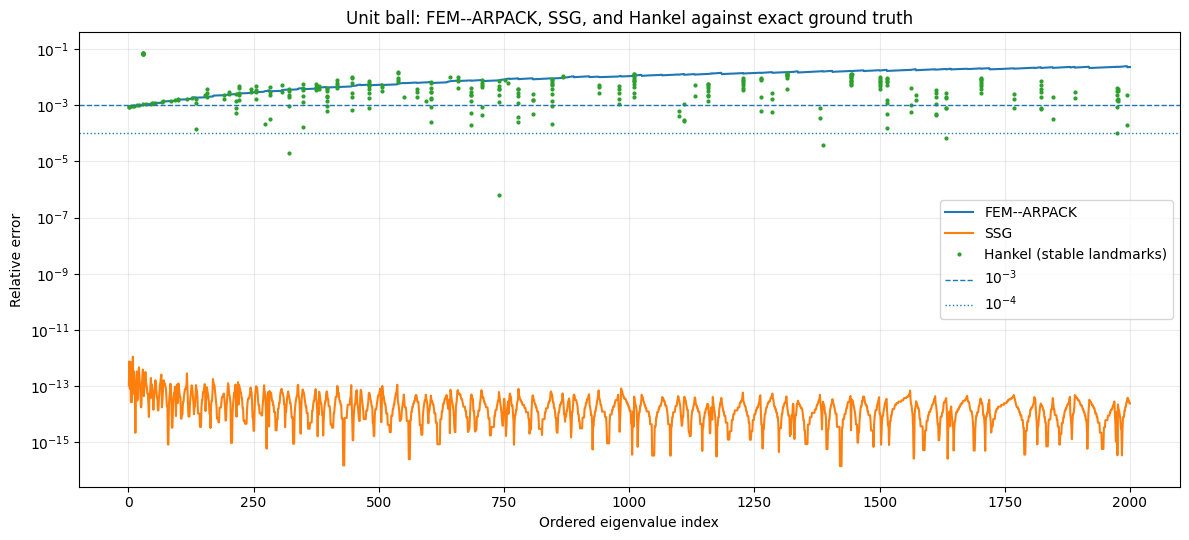

saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_fem_ssg_hankel_relative_error.pdf
saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_fem_ssg_hankel_relative_error.png


In [25]:
# ============================================================
# Unit ball: FEM, SSG, and Hankel errors against exact spectrum
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- adjust if needed
HANKEL_ANALYSIS = Path(
    "/home/esul01/data/outputs/hankel_resolvent_sphere/analysis/hankel_seed_aware_landmarks.csv"
)

# Load stable Hankel landmarks
df_hankel = pd.read_csv(HANKEL_ANALYSIS)

# Exact ordered spectrum already implicit in ordered_results
# We use the exact spectrum from one of the ordered result tables.
df_exact_ref = ordered_results["SSG"][["index", "lambda_exact"]].copy()
df_exact_ref = df_exact_ref.sort_values("index").reset_index(drop=True)

exact_vals = df_exact_ref["lambda_exact"].to_numpy()
exact_idx  = df_exact_ref["index"].to_numpy()

# Match each Hankel landmark to the nearest exact ordered eigenvalue
lam_h = df_hankel["lambda_center"].to_numpy()

match_pos = np.abs(exact_vals[:, None] - lam_h[None, :]).argmin(axis=0)
df_hankel["exact_index"] = exact_idx[match_pos]
df_hankel["lambda_exact"] = exact_vals[match_pos]
df_hankel["rel_error"] = np.abs(df_hankel["lambda_center"] - df_hankel["lambda_exact"]) / np.maximum(
    np.abs(df_hankel["lambda_exact"]), 1e-300
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5.5))

for method in ["FEM--ARPACK", "SSG"]:
    df = ordered_results[method]
    ax.semilogy(
        df["index"],
        np.maximum(df["rel_error"], 1e-16),
        label=method,
    )

# Hankel as sparse landmarks
ax.semilogy(
    df_hankel["exact_index"],
    np.maximum(df_hankel["rel_error"], 1e-16),
    linestyle="none",
    marker=".",
    markersize=4,
    label="Hankel (stable landmarks)",
)

ax.axhline(1e-3, linestyle="--", linewidth=1, label=r"$10^{-3}$")
ax.axhline(1e-4, linestyle=":", linewidth=1, label=r"$10^{-4}$")

ax.set_xlabel("Ordered eigenvalue index")
ax.set_ylabel("Relative error")
ax.set_title("Unit ball: FEM--ARPACK, SSG, and Hankel against exact ground truth")
ax.legend()
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()

pdf_path = FIG_DIR / "unit_ball_fem_ssg_hankel_relative_error.pdf"
png_path = FIG_DIR / "unit_ball_fem_ssg_hankel_relative_error.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("saved:", pdf_path)
print("saved:", png_path)

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd

analysis = Path(
    "/home/esul01/data/outputs/hankel_resolvent_sphere/analysis"
)
exact_path = Path(
    "/home/esul01/data/outputs/unit_ball_ground_truth_validation/"
    "unit_ball_exact_levels_to_N2000.csv"
)
landmark_path = analysis / "hankel_seed_aware_landmarks.csv"

exact = pd.read_csv(exact_path).sort_values("lambda_exact").reset_index(drop=True)
landmarks = pd.read_csv(landmark_path).sort_values("lambda_center").reset_index(drop=True)

# Restrict to the exact N=2000 spectral range.
lambda_min = np.pi**2
lambda_max = 1001.697694941389

landmarks = landmarks[
    landmarks["lambda_center"].between(lambda_min, lambda_max)
].copy()

levels = exact["lambda_exact"].to_numpy()
values = landmarks["lambda_center"].to_numpy()

pos = np.searchsorted(levels, values)
left_idx = np.clip(pos - 1, 0, len(levels) - 1)
right_idx = np.clip(pos, 0, len(levels) - 1)

left_err = np.abs(values - levels[left_idx])
right_err = np.abs(values - levels[right_idx])

nearest_idx = np.where(right_err < left_err, right_idx, left_idx)
nearest = levels[nearest_idx]

landmarks["exact_level_index"] = nearest_idx
landmarks["lambda_exact"] = nearest
landmarks["l"] = exact.iloc[nearest_idx]["l"].to_numpy()
landmarks["radial_index"] = exact.iloc[nearest_idx]["radial_index"].to_numpy()
landmarks["multiplicity"] = exact.iloc[nearest_idx]["multiplicity"].to_numpy()
landmarks["exact_abs_rel_err"] = np.abs(values - nearest) / nearest

# Best landmark per exact level, so duplicates around one level do not inflate coverage.
best = (
    landmarks.sort_values("exact_abs_rel_err")
    .drop_duplicates("exact_level_index", keep="first")
    .sort_values("lambda_center")
)

n_exact_levels = len(exact)
n_distinct_hit = best["exact_level_index"].nunique()

summary = {
    "n_stable_landmarks": len(landmarks),
    "n_exact_distinct_levels": n_exact_levels,
    "n_distinct_levels_hit": n_distinct_hit,
    "distinct_level_coverage": n_distinct_hit / n_exact_levels,
    "median_exact_abs_rel_err_all_landmarks":
        landmarks["exact_abs_rel_err"].median(),
    "max_exact_abs_rel_err_all_landmarks":
        landmarks["exact_abs_rel_err"].max(),
    "median_exact_abs_rel_err_best_per_level":
        best["exact_abs_rel_err"].median(),
    "max_exact_abs_rel_err_best_per_level":
        best["exact_abs_rel_err"].max(),
    "hits_1e-3_all_landmarks":
        int((landmarks["exact_abs_rel_err"] <= 1e-3).sum()),
    "hits_1e-4_all_landmarks":
        int((landmarks["exact_abs_rel_err"] <= 1e-4).sum()),
    "hits_1e-5_all_landmarks":
        int((landmarks["exact_abs_rel_err"] <= 1e-5).sum()),
    "distinct_levels_hit_1e-3":
        int((best["exact_abs_rel_err"] <= 1e-3).sum()),
    "distinct_levels_hit_1e-4":
        int((best["exact_abs_rel_err"] <= 1e-4).sum()),
    "distinct_levels_hit_1e-5":
        int((best["exact_abs_rel_err"] <= 1e-5).sum()),
}

pd.Series(summary).to_json(
    analysis / "hankel_vs_exact_sphere_summary.json",
    indent=2,
)
landmarks.to_csv(
    analysis / "hankel_vs_exact_sphere_all_landmarks.csv",
    index=False,
)
best.to_csv(
    analysis / "hankel_vs_exact_sphere_best_per_level.csv",
    index=False,
)

print(pd.Series(summary).to_string())

print("\nWorst 15 landmarks:")
print(
    landmarks.nlargest(15, "exact_abs_rel_err")[
        [
            "lambda_center",
            "n_seeds",
            "lambda_exact",
            "l",
            "radial_index",
            "exact_abs_rel_err",
        ]
    ].to_string(index=False)
)

n_stable_landmarks                         312.000000
n_exact_distinct_levels                    119.000000
n_distinct_levels_hit                       88.000000
distinct_level_coverage                      0.739496
median_exact_abs_rel_err_all_landmarks       0.003011
max_exact_abs_rel_err_all_landmarks          0.072872
median_exact_abs_rel_err_best_per_level      0.001265
max_exact_abs_rel_err_best_per_level         0.012705
hits_1e-3_all_landmarks                     55.000000
hits_1e-4_all_landmarks                      4.000000
hits_1e-5_all_landmarks                      1.000000
distinct_levels_hit_1e-3                    38.000000
distinct_levels_hit_1e-4                     4.000000
distinct_levels_hit_1e-5                     1.000000

Worst 15 landmarks:
 lambda_center  n_seeds  lambda_exact  l  radial_index  exact_abs_rel_err
     76.691319        4     82.719231  2             2           0.072872
     76.829692        6     82.719231  2             2           0.071199
 

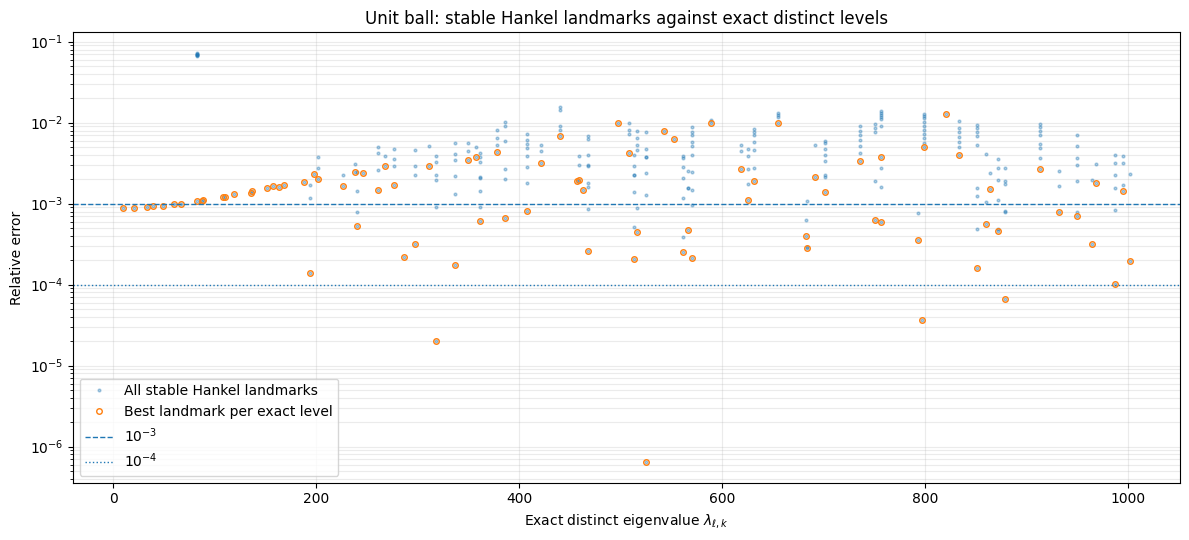

saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_hankel_relative_error_vs_exact_level.pdf
saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_hankel_relative_error_vs_exact_level.png


In [18]:
# ============================================================
# Unit ball: Hankel landmark error against exact distinct levels
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

analysis_dir = Path(
    "/home/esul01/data/outputs/hankel_resolvent_sphere/analysis"
)

all_landmarks = pd.read_csv(
    analysis_dir / "hankel_vs_exact_sphere_all_landmarks.csv"
)

best_per_level = pd.read_csv(
    analysis_dir / "hankel_vs_exact_sphere_best_per_level.csv"
)

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.semilogy(
    all_landmarks["lambda_exact"],
    np.maximum(all_landmarks["exact_abs_rel_err"], 1e-16),
    linestyle="none",
    marker=".",
    markersize=4,
    alpha=0.35,
    label="All stable Hankel landmarks",
)

ax.semilogy(
    best_per_level["lambda_exact"],
    np.maximum(best_per_level["exact_abs_rel_err"], 1e-16),
    linestyle="none",
    marker="o",
    markersize=4,
    markerfacecolor="none",
    label="Best landmark per exact level",
)

ax.axhline(1e-3, linestyle="--", linewidth=1, label=r"$10^{-3}$")
ax.axhline(1e-4, linestyle=":", linewidth=1, label=r"$10^{-4}$")

ax.set_xlabel(r"Exact distinct eigenvalue $\lambda_{\ell,k}$")
ax.set_ylabel("Relative error")
ax.set_title(
    "Unit ball: stable Hankel landmarks against exact distinct levels"
)
ax.legend()
ax.grid(True, which="both", alpha=0.25)

fig.tight_layout()

pdf_path = FIG_DIR / "unit_ball_hankel_relative_error_vs_exact_level.pdf"
png_path = FIG_DIR / "unit_ball_hankel_relative_error_vs_exact_level.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("saved:", pdf_path)
print("saved:", png_path)

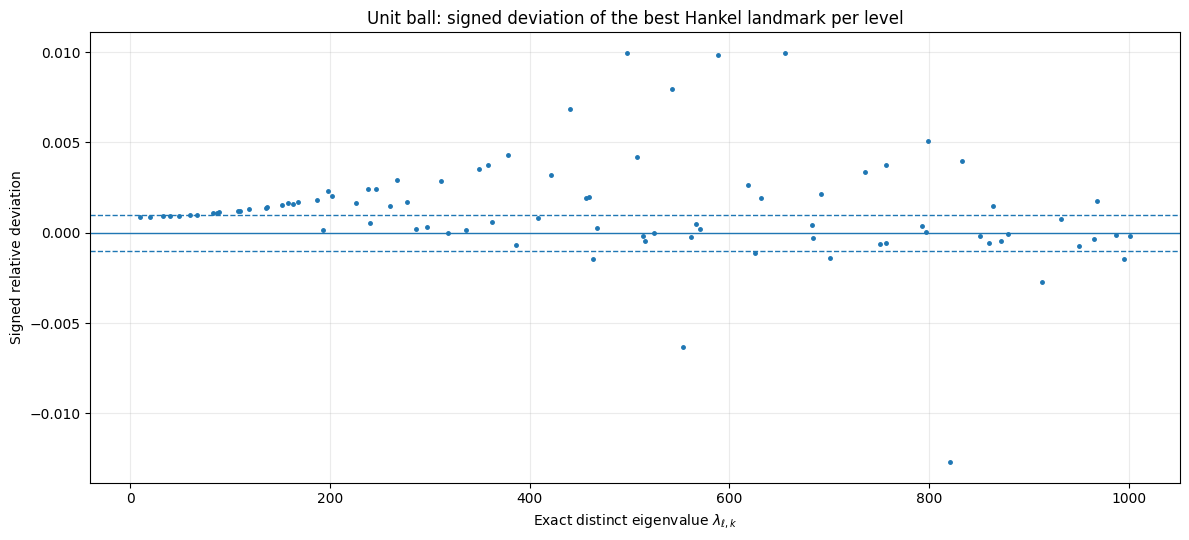

In [19]:
# ============================================================
# Signed relative deviation of Hankel landmarks
# ============================================================

best = best_per_level.copy()

best["signed_rel_error"] = (
    best["lambda_center"] - best["lambda_exact"]
) / best["lambda_exact"]

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.axhline(0.0, linewidth=1)

ax.plot(
    best["lambda_exact"],
    best["signed_rel_error"],
    linestyle="none",
    marker=".",
    markersize=5,
)

ax.axhline(1e-3, linestyle="--", linewidth=1)
ax.axhline(-1e-3, linestyle="--", linewidth=1)

ax.set_xlabel(r"Exact distinct eigenvalue $\lambda_{\ell,k}$")
ax.set_ylabel("Signed relative deviation")
ax.set_title(
    "Unit ball: signed deviation of the best Hankel landmark per level"
)
ax.grid(True, alpha=0.25)

fig.tight_layout()

pdf_path = FIG_DIR / "unit_ball_hankel_signed_relative_deviation.pdf"
png_path = FIG_DIR / "unit_ball_hankel_signed_relative_deviation.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

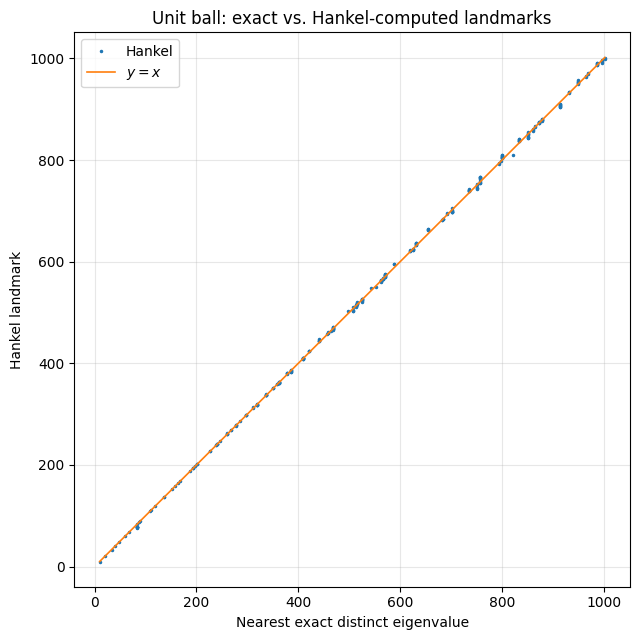

saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_exact_vs_hankel.pdf
saved: /home/esul01/data/outputs/unit_ball_ground_truth_validation/figures/unit_ball_exact_vs_hankel.png


In [24]:
# ============================================================
# Unit ball: exact vs. Hankel landmarks
# ============================================================

x = all_landmarks["lambda_exact"].to_numpy()
y = all_landmarks["lambda_center"].to_numpy()

fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.plot(
    x,
    y,
    linestyle="none",
    marker=".",
    markersize=3,
    label="Hankel",
)

lo = min(x.min(), y.min())
hi = max(x.max(), y.max())

ax.plot(
    [lo, hi],
    [lo, hi],
    linewidth=1.2,
    label=r"$y=x$",
)

ax.set_xlabel("Nearest exact distinct eigenvalue")
ax.set_ylabel("Hankel landmark")
ax.set_title("Unit ball: exact vs. Hankel-computed landmarks")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()

pdf_path = FIG_DIR / "unit_ball_exact_vs_hankel.pdf"
png_path = FIG_DIR / "unit_ball_exact_vs_hankel.png"

fig.savefig(pdf_path, bbox_inches="tight")
fig.savefig(png_path, dpi=300, bbox_inches="tight")

plt.show()

print("saved:", pdf_path)
print("saved:", png_path)